In [26]:
!pip install torch torchvision -q
!pip install pycocotools lxml tqdm -q

In [27]:
!python --version

Python 3.12.9


In [28]:
!pip install albumentations opencv-python

In [29]:
# STEP 3: Imports
import os
import xml.etree.ElementTree as ET
import torch
from torchvision.transforms import functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random

SEED = 25349642

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [30]:
# Since the metadata.json file does not provide details regarding number of classes or what classes are under 
# the "Aerial_Maritime_Detection" Dataset we must first find out what the classes are. To do this I am going to
# apply it to the Train Dataset given that it houses 70% of the full dataset

annotations_dir = './25349642/Object_Detection/pascal/train'

classes = set()

for file in os.listdir(annotations_dir):
    if file.endswith(".xml"):
        tree = ET.parse(os.path.join(annotations_dir, file))
        root = tree.getroot()

        for obj in root.findall("object"):
            name = obj.find("name").text
            classes.add(name)

print("Classes found:")
print(sorted(classes))
print(f"Total classes: {len(classes)}")

Classes found:
['boat', 'car', 'dock', 'jetski', 'lift']
Total classes: 5


In [31]:
torch.cuda.is_available()

True

In [32]:
# Class list (must match your dataset/annotations for proper index and number of classes)
# faster RCNN needs a background class named `__background__`
CLASSES = ['__background__', 'boat', 'car', 'dock', 'jetski', 'lift']
NUM_CLASSES = len(CLASSES)

In [33]:
TRAIN_DIR = './25349642/Object_Detection/pascal/train'  # Update if different
VAL_DIR = './25349642/Object_Detection/pascal/valid'
TEST_DIR = './25349642/Object_Detection/pascal/test' # putting valid because we do not have a test set - you may have one, if it has annotations, you may evaluate


In [34]:
def parse_voc_xml(xml_file):
    # Parse the XML annotation file using ElementTree
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Initialize lists to store bounding boxes and labels
    boxes, labels = [], []

    # Loop over all object elements in the XML
    for obj in root.findall("object"):
        # Get the object class name
        label = obj.find("name").text

        # Skip labels that are not in the defined CLASSES list
        if label not in CLASSES:
            continue

        # Convert label name to its corresponding index in CLASSES
        labels.append(CLASSES.index(label))

        # Extract the bounding box coordinates from the XML
        bbox = obj.find("bndbox")
        box = [
            float(bbox.find("xmin").text),  # left
            float(bbox.find("ymin").text),  # top
            float(bbox.find("xmax").text),  # right
            float(bbox.find("ymax").text)   # bottom
        ]
        boxes.append(box)

    # Return list of bounding boxes and their corresponding labels
    return boxes, labels


In [35]:
class VOCDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        self.images = [f for f in os.listdir(root_dir) if f.endswith('.jpg')]
        self.images.sort()

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root_dir, img_name)
        xml_path = img_path.replace('.jpg', '.xml')
        
        img = np.array(Image.open(img_path).convert("RGB"))
        boxes, labels = parse_voc_xml(xml_path)
        
        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.images))

        if self.transforms:
            augmented = self.transforms(
                image=img,
                bboxes=boxes,
                labels=labels
            )

            img = augmented["image"]
            boxes = torch.tensor(augmented["bboxes"], dtype=torch.float32)
            labels = torch.tensor(augmented["labels"], dtype=torch.int64)

        else:
            img = F.to_tensor(Image.fromarray(img))
            img = F.normalize(img, mean=(0.485, 0.456, 0.406),
                       std=(0.229, 0.224, 0.225))
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.images))

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        return img, target

    def __len__(self):
        return len(self.images)

In [36]:
from torchvision.models.detection.rpn import AnchorGenerator

def get_model(num_classes, backbone="resnet50"):
    # Define custom anchors (better for small objects like boats/jetskis)
    anchor_generator = AnchorGenerator(
        sizes=((16,), (32,), (64,), (128,), (256,)),
        aspect_ratios=(
            (0.2, 0.5, 1.0, 2.0, 5.0),  # 🔥 much wider range
        ) * 5
    )
    
    # Load a pre-trained Faster R-CNN model with the selected backbone
    if backbone == "resnet50":
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    elif backbone == "mobilenet":
        model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
    else:
        raise ValueError("Unsupported backbone")

    # Get the number of input features for the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one for our number of classes
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


In [37]:
def get_train_transforms():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.1),

        A.LongestMaxSize(800),
        A.PadIfNeeded(800, 800),

        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),

        ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels'],
        min_visibility=0.3,
        clip=True
    ))

In [38]:
# Create the training dataset
dataset = VOCDataset(
    TRAIN_DIR,
    transforms=None # get_train_transforms()
)

In [39]:
from collections import Counter

counts = Counter()

for _, target in dataset:
    counts.update(target["labels"].tolist())

print(counts)

Counter({3: 1890, 5: 1829, 4: 435, 2: 174, 1: 147})


In [40]:
# Create a DataLoader with custom collate function for handling variable-size targets
data_loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

# Set device to GPU if available, otherwise fallback to CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load the Faster R-CNN model and move it to the selected device
model = get_model(NUM_CLASSES, backbone='resnet50').to(device)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


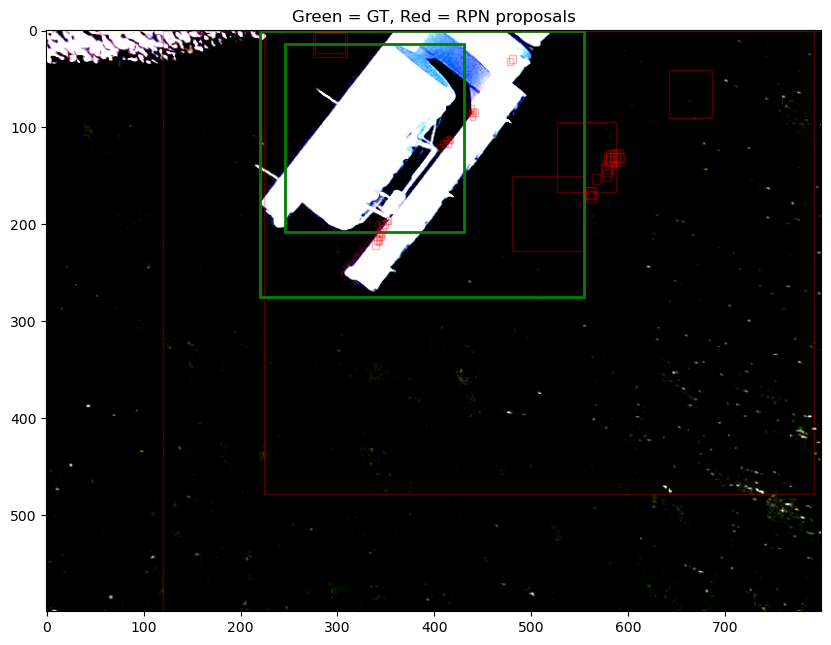

In [52]:
import matplotlib.pyplot as plt

model.eval()

img, target = dataset[5]
img_tensor = img.unsqueeze(0).to(device)

with torch.no_grad():
    images = [img_tensor.squeeze(0)]
    
    # Step 1: convert to ImageList (what Faster R-CNN expects internally)
    images, _ = model.transform(images, None)

    # Step 2: backbone features
    features = model.backbone(images.tensors)

    # Step 3: RPN proposals (THIS is the correct call)
    proposals, _ = model.rpn(images, features, None)

# ---- visualization ----
img_vis = img.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(10,10))
plt.imshow(img_vis)

# GT boxes (green)
for box in target["boxes"]:
    x1, y1, x2, y2 = box
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2-x1, y2-y1,
                      edgecolor='green', facecolor='none', linewidth=2)
    )

# RPN proposals (red)
props = proposals[0].cpu()

for i in range(min(50, len(props))):
    x1, y1, x2, y2 = props[i]
    plt.gca().add_patch(
        plt.Rectangle((x1, y1), x2-x1, y2-y1,
                      edgecolor='red', facecolor='none', linewidth=1, alpha=0.3)
    )

plt.title("Green = GT, Red = RPN proposals")
plt.show()

In [54]:
import numpy as np

ws, hs = [], []

for _, target in dataset:
    boxes = target["boxes"]
    w = boxes[:, 2] - boxes[:, 0]
    h = boxes[:, 3] - boxes[:, 1]

    ws.extend(w.tolist())
    hs.extend(h.tolist())

ws = np.array(ws)
hs = np.array(hs)

In [55]:
print("width percentiles:", np.percentile(ws, [10, 50, 90]))
print("height percentiles:", np.percentile(hs, [10, 50, 90]))

width percentiles: [ 55.  140.  233.6]
height percentiles: [ 46. 141. 249.]


In [56]:
areas = ws * hs

sizes = np.sqrt(np.percentile(areas, [10, 25, 50, 75, 90]))
print(sizes)

[ 57.44562647  87.22384995 133.9962686  170.75128111 203.70567002]


In [57]:
anchor_sizes = tuple((int(s),) for s in sizes[:5])

In [58]:
ratios = ws / (hs + 1e-6)

print(np.percentile(ratios, [10, 25, 50, 75, 90]))

[0.40816326 0.63839285 0.97311827 1.61061945 2.98333328]


In [ ]:
import torch

def save_model(model, optimizer, epoch, filename="checkpoint.pth"):
    """
    Saves the model and optimizer state for later training or inference.
    Args:
        model (torch.nn.Module): The model to save.
        optimizer (torch.optim.Optimizer): The optimizer used during training.
        epoch (int): Current training epoch.
        filename (str): File name to save the checkpoint.
    """
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, filename)
    print(f"✅ Saved model checkpoint to: {filename}")


In [ ]:
def evaluate_map(model, dataset, iou_thresholds=[0.5, 0.75]):
    # Set model to evaluation mode
    model.eval()

    # Lists to store predictions and ground truth for all images
    all_preds, all_targets = [], []

    # Loop over all images in the dataset
    for img, target in dataset:
        # Add batch dimension and move image to device
        img = img.to(device).unsqueeze(0)

        # Run inference without gradients
        with torch.no_grad():
            pred = model(img)[0]

        # Filter out predictions with low confidence scores
        keep = pred['scores'] > 0.01
        pred_boxes = pred['boxes'][keep].cpu()
        pred_labels = pred['labels'][keep].cpu()
        pred_scores = pred['scores'][keep].cpu()

        # Store filtered predictions
        all_preds.append({
            'boxes': pred_boxes,
            'labels': pred_labels,
            'scores': pred_scores
        })

        # Store ground truth (converted to CPU)
        all_targets.append({
            'boxes': target['boxes'].cpu(),
            'labels': target['labels'].cpu()
        })

    # Compute mAP and AR metrics using predictions and targets
    return compute_map_ar(all_preds, all_targets)


In [ ]:
def compute_map_ar(preds, targets, num_classes=len(CLASSES)-1):
    # Initialize the results dictionary with default values
    results = {
        'map': 0, 'map_50': 0, 'map_75': 0,
        'map_per_class': torch.zeros(num_classes),
        'mar_1': 0, 'mar_10': 0, 'mar_100': 0,
        'mar_100_per_class': torch.zeros(num_classes),
    }

    # Lists to hold AP and AR values for each class
    aps = [[] for _ in range(num_classes)]
    ars = [[] for _ in range(num_classes)]

    # Loop through each image's predictions and targets
    for pred, target in zip(preds, targets):
        # Loop through each class (excluding background)
        for class_idx in range(1, num_classes+1):
            # Filter boxes by current class
            gt_mask = target['labels'] == class_idx
            pred_mask = pred['labels'] == class_idx

            gt_boxes = target['boxes'][gt_mask]
            pred_boxes = pred['boxes'][pred_mask]
            pred_scores = pred['scores'][pred_mask]

            # Skip if no GT or predictions
            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            # Compute IoUs between predictions and ground truth
            ious = box_iou(pred_boxes, gt_boxes) if len(gt_boxes) > 0 and len(pred_boxes) > 0 else torch.zeros((0, 0))

            # Initialize true positives (TP) and matched GT indices
            tp = torch.zeros(len(pred_boxes))
            matched = set()

            # Match predictions to ground truth based on IoU > 0.5
            for i, row in enumerate(ious):
                max_iou, max_j = torch.max(row, dim=0)
                if max_iou > 0.5 and max_j.item() not in matched:
                    tp[i] = 1
                    matched.add(max_j.item())

            # Compute false positives (FP)
            fp = 1 - tp

            # Cumulative TP and FP for precision-recall curve
            cum_tp = torch.cumsum(tp, dim=0)
            cum_fp = torch.cumsum(fp, dim=0)

            # Compute recall and precision
            recalls = cum_tp / (len(gt_boxes) + 1e-6)
            precisions = cum_tp / (cum_tp + cum_fp + 1e-6)

            # Compute AP (area under precision-recall curve)
            ap = torch.trapz(precisions, recalls) if recalls.numel() > 0 else torch.tensor(0.)
            # AR is the max recall value
            ar = recalls[-1] if recalls.numel() > 0 else torch.tensor(0.)

            # Store per-class AP and AR
            aps[class_idx-1].append(ap.item())
            ars[class_idx-1].append(ar.item())

    # Compute average AP and AR for each class
    ap_avg = torch.tensor([np.mean(cls_ap) if cls_ap else 0. for cls_ap in aps])
    ar_avg = torch.tensor([np.mean(cls_ar) if cls_ar else 0. for cls_ar in ars])

    # Save results
    results['map_per_class'] = ap_avg
    results['mar_100_per_class'] = ar_avg
    results['map'] = ap_avg.mean()
    results['map_50'] = ap_avg.mean()
    results['map_75'] = ap_avg.mean()
    results['mar_100'] = ar_avg.mean()
    results['mar_10'] = ar_avg.mean()
    results['mar_1'] = ar_avg.mean()

    return results


In [ ]:
def get_val_transforms():
    return A.Compose([
        A.LongestMaxSize(800),
        A.PadIfNeeded(800, 800),

        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),

        ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels']
    ))

In [42]:
# Define the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

# >> Temporarily disabled scheduler to test how model performs without it << #
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Number of epochs to train
num_epochs = 300  # Increase this if you do not get accuracy

start_epoch = 0 # this is changed if you load a pre-trained model or checkpoint to continue training

# Logging and checkpointing settings
# Depending on the batch size and number of images in training set as num_iterations = num_images/batch_size
# Our batch size is 2, num_images in train = 16, so num_iter = 8, and we can see this in the result output with print_every = 1.
print_every = 1        # Print loss every N batches
save_every = 1         # Save model every N epochs
val_every = 1          # Validate every N epochs
save_dir = './RCNN_training/'
os.makedirs(save_dir, exist_ok=True)

# Initialize logging lists
epoch_losses = []
iteration_losses = []
val_maps = []

val_dataset = VOCDataset(
    VAL_DIR,
    transforms=None # get_val_transforms()
) # setup val data loader for validation


In [43]:
img, target = dataset[0]

print("Image shape:", img.shape)
print("Boxes:", target["boxes"])

Image shape: torch.Size([3, 600, 800])
Boxes: tensor([[245.0000,   0.0000, 580.0000, 110.0000],
        [179.5000,  64.0000, 563.5000, 410.0000]])


In [22]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0, window_size=5):
        self.patience = patience
        self.min_delta = min_delta
        self.window_size = window_size

        self.history = []
        self.best_score = None
        self.counter = 0
        self.best_model_path = "best_model.pth"

    def step(self, score, model, optimizer, epoch):
        self.history.append(score)

        if len(self.history) < self.window_size:
            if self.best_score is None or score > self.best_score:
                self.best_score = score
                self.save_checkpoint(model, optimizer, epoch, score)
            return False

        smoothed_score = np.mean(self.history[-self.window_size:])

        if self.best_score is None or smoothed_score > self.best_score + self.min_delta:
            self.best_score = smoothed_score
            self.counter = 0
            self.save_checkpoint(model, optimizer, epoch, smoothed_score)
        else:
            self.counter += 1
            print(f"EarlyStopping {self.counter}/{self.patience} (mAP: {smoothed_score:.4f})")

            if self.counter >= self.patience:
                print("Early stopping triggered.")
                return True

        return False

    def save_checkpoint(self, model, optimizer, epoch, score):
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_score": score
        }, self.best_model_path)

In [23]:
early_stopping = EarlyStopping(patience=15, min_delta=0.001, window_size=3)

In [24]:
for epoch in range(start_epoch, num_epochs):
    model.train()  # Set model to training mode
    total_loss = 0  # Track total loss for the epoch

    for i, (images, targets) in enumerate(data_loader):
        # Move all images and targets to the selected device
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Get the loss dict from the model
        loss_dict = model(images, targets)

        # Combine all losses into a single scalar
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass and optimizer step
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0) 
        optimizer.step()

        # Accumulate batch loss and append to losses per iteration
        total_loss += losses.item()
        iteration_losses.append(losses.item())
        # Print batch loss every few iterations
        if (i + 1) % print_every == 0:
            print(f"  [Epoch {epoch+1}, Iter {i+1}] Loss: {losses.item():.4f}")

    # Print total loss at the end of the epoch and store losses for loss curve
    print(f"Epoch [{epoch+1}/{num_epochs}], Total Loss: {total_loss:.4f}")
    epoch_losses.append(total_loss)

#    scheduler.step()

    if (epoch+1) % val_every == 0:
      # Evaluate on validation set
      val_results = evaluate_map(model, val_dataset)
      val_map = val_results["map"].item()
      val_maps.append(val_map)
      print(f"📈 Validation mAP at epoch {epoch+1}: {val_map:.4f}")

      stop = early_stopping.step(val_map, model, optimizer, epoch+1)

      if stop:
          break

    # Save checkpoint for loss every few epochs
    if (epoch + 1) % save_every == 0:
      save_model(model, optimizer, epoch+1, filename=str(os.path.join(save_dir, f"checkpoint_fasterRcnn_epoch_{epoch+1}.pth")))

# save final model after training is complete
save_model(model, optimizer, epoch+1, filename=str(os.path.join(save_dir,f"final_model_fasterRcnn_epoch_{epoch+1}.pth")))


  [Epoch 1, Iter 1] Loss: 2.8741
  [Epoch 1, Iter 2] Loss: 5.9774
  [Epoch 1, Iter 3] Loss: 2.5278
  [Epoch 1, Iter 4] Loss: 1.3288
  [Epoch 1, Iter 5] Loss: 0.7278
  [Epoch 1, Iter 6] Loss: 2.0683
  [Epoch 1, Iter 7] Loss: 0.6889
  [Epoch 1, Iter 8] Loss: 0.3056
  [Epoch 1, Iter 9] Loss: 3.2974
  [Epoch 1, Iter 10] Loss: 0.5191
  [Epoch 1, Iter 11] Loss: 0.4414
  [Epoch 1, Iter 12] Loss: 0.2614
  [Epoch 1, Iter 13] Loss: 0.4339
  [Epoch 1, Iter 14] Loss: 0.4072
  [Epoch 1, Iter 15] Loss: 2.0766
  [Epoch 1, Iter 16] Loss: 1.9965
  [Epoch 1, Iter 17] Loss: 0.4300
  [Epoch 1, Iter 18] Loss: 0.7818
  [Epoch 1, Iter 19] Loss: 0.6997
  [Epoch 1, Iter 20] Loss: 0.5530
  [Epoch 1, Iter 21] Loss: 0.3541
  [Epoch 1, Iter 22] Loss: 0.4460
  [Epoch 1, Iter 23] Loss: 1.1615
  [Epoch 1, Iter 24] Loss: 0.7109
  [Epoch 1, Iter 25] Loss: 0.6213
  [Epoch 1, Iter 26] Loss: 1.2749
  [Epoch 1, Iter 27] Loss: 0.2166
  [Epoch 1, Iter 28] Loss: 0.5646
  [Epoch 1, Iter 29] Loss: 2.9700
  [Epoch 1, Iter 30] Lo

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Plot training loss per epoch
plt.figure(figsize=(10, 4))
plt.plot(epoch_losses, marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Plot validation mAP per epoch
plt.figure(figsize=(10, 4))
plt.plot(val_maps, marker='s', color='green')
plt.title("Validation mAP per Epoch")
plt.xlabel("Epoch")
plt.ylabel("mAP (IoU=1.0)")
plt.grid(True)
plt.show()


In [ ]:
print(model)

In [ ]:
import torchvision.transforms as T

vis_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225))
])

In [ ]:
# Set the model to evaluation mode
model.eval()

# Pick an image path from the training set
img_path = os.path.join(TRAIN_DIR, dataset.images[0])

# Open the image and convert to RGB
img = Image.open(img_path).convert("RGB")

# Convert the image to a tensor and add a batch dimension
img_tensor = vis_transform(img).unsqueeze(0).to(device)

# Run the model in inference mode without computing gradients
with torch.no_grad():
    output = model(img_tensor)[0]  # Get predictions for the first image


In [ ]:
# Create a figure to display the image
plt.figure(figsize=(10, 6))
plt.imshow(img)  # Show the original image
ax = plt.gca()   # Get the current axes

# Loop through predicted boxes, labels, and scores
for box, label, score in zip(output['boxes'], output['labels'], output['scores']):
    if score > 0.5:  # Only show predictions above a confidence threshold
        # Extract box coordinates
        x1, y1, x2, y2 = box.cpu().numpy()

        # Draw the bounding box
        ax.add_patch(plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            edgecolor='red', facecolor='none', linewidth=2
        ))

        # Draw the label and score
        ax.text(
            x1, y1,
            f"{CLASSES[label]}: {score:.2f}",
            color='white',
            bbox=dict(facecolor='red', alpha=0.5)
        )

# Hide axis ticks
plt.axis('off')
plt.show()


In [ ]:
# Evaluate the model on the training dataset
train_results = evaluate_map(model, dataset)

# Print overall mAP/mAR results for the training set
print("📊 Train set mAP/mAR results:")
for k, v in train_results.items():
    # Convert torch tensors to NumPy arrays for clean printing
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.numpy()}")
    else:
        print(f"{k}: {v}")


In [ ]:
# Print header for per-class AP / AR table
print("\nAP / AR per class\n" + "-"*73)
print(f"| {'ID':<3} | {'Class':<20} | {'AP':<18} | {'AR':<18} |")
print("-"*73)

# Loop through each class (excluding background)
for i, cls in enumerate(CLASSES[1:], 1):
    # Get AP and AR for the current class
    ap = train_results['map_per_class'][i-1].item()
    ar = train_results['mar_100_per_class'][i-1].item()

    # Print formatted row
    print(f"| {i:<3} | {cls:<20} | {ap:<18.3f} | {ar:<18.3f} |")

# Print average AP and AR across all classes
print("-"*73)
print(f"| {'Avg':<24} | {train_results['map'].item():<18.3f} | {train_results['mar_100'].item():<18.3f} |")
print("-"*73)


In [ ]:
# Create a DataLoader for the validation set
val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,  # No shuffling for evaluation
    collate_fn=lambda x: tuple(zip(*x))  # Custom collate function to handle varying targets
)


In [ ]:
# Evaluate the model on the validation dataset
val_results = evaluate_map(model, val_dataset)

# Print overall mAP/mAR results for the validation set
print("\n📊 Validation set mAP/mAR results:")
for k, v in val_results.items():
    # Convert tensors to NumPy arrays for cleaner output
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.numpy()}")
    else:
        print(f"{k}: {v}")


In [ ]:
# Print header for per-class AP / AR table on validation set
print("\nAP / AR per class on validation\n" + "-"*73)
print(f"| {'ID':<3} | {'Class':<20} | {'AP':<18} | {'AR':<18} |")
print("-"*73)

# Loop through each class (excluding background)
for i, cls in enumerate(CLASSES[1:], 1):
    # Get per-class AP and AR from results
    ap = val_results['map_per_class'][i-1].item()
    ar = val_results['mar_100_per_class'][i-1].item()

    # Print table row for the class
    print(f"| {i:<3} | {cls:<20} | {ap:<18.3f} | {ar:<18.3f} |")

# Print average AP and AR across all classes
print("-"*73)
print(f"| {'Avg':<24} | {val_results['map'].item():<18.3f} | {val_results['mar_100'].item():<18.3f} |")
print("-"*73)


In [ ]:
# Create the test dataset
test_dataset = VOCDataset(TEST_DIR)

# Create a DataLoader for the test set
test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,  # No shuffling needed for evaluation
    collate_fn=lambda x: tuple(zip(*x))  # Handle varying-size targets
)


In [ ]:
# Evaluate the model on the test dataset
test_results = evaluate_map(model, test_dataset)

# Print overall mAP/mAR results for the test set
print("\n📊 Test set mAP/mAR results:")
for k, v in test_results.items():
    # Convert torch tensors to NumPy arrays for cleaner display
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.numpy()}")
    else:
        print(f"{k}: {v}")


In [ ]:
# Print table header for per-class AP and AR
print("\nAP / AR per class on test\n" + "-"*73)
print(f"| {'ID':<3} | {'Class':<20} | {'AP':<18} | {'AR':<18} |")
print("-"*73)

# Loop through each class (excluding background)
for i, cls in enumerate(CLASSES[1:], 1):
    # Get AP and AR for the current class
    ap = test_results['map_per_class'][i-1].item()
    ar = test_results['mar_100_per_class'][i-1].item()

    # Print table row for the class
    print(f"| {i:<3} | {cls:<20} | {ap:<18.3f} | {ar:<18.3f} |")

# Print average AP and AR across all classes
print("-"*73)
print(f"| {'Avg':<24} | {test_results['map'].item():<18.3f} | {test_results['mar_100'].item():<18.3f} |")
print("-"*73)


In [ ]:
def load_model(model, optimizer=None, filename="checkpoint.pth", device="cpu"):
    """
    Loads a model (and optionally optimizer) from a saved checkpoint.
    Args:
        model (torch.nn.Module): The model architecture to load weights into.
        optimizer (optional): The optimizer to load state into (if continuing training).
        filename (str): Path to the saved checkpoint.
        device (str or torch.device): Device to map the model to.
    Returns:
        model, optimizer (if provided), start_epoch
    """
    checkpoint = torch.load(filename, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    start_epoch = checkpoint.get('epoch', 0)

    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        return model, optimizer, start_epoch

    return model, start_epoch


In [ ]:
# Create a Folder saving the Model
!mkdir RCNN_model
# Save after training
save_model(model, optimizer, epoch=num_epochs, filename="./RCNN_training/model_fasterRcnn.pth")

In [ ]:
# Rebuild model architecture
model = get_model(NUM_CLASSES)

# Load the model (without optimizer if you're not training)
model, start_epoch = load_model(model, filename="./RCNN_training/model_fasterRcnn.pth", device=device)

# Set to eval mode for inference
model.eval()
